#Amit pawar
#25070126501
#Support_Vector_Machine.

INFORMATION

The model applied to the heart disease dataset performed exceptionally well, achieving an accuracy of 99% on the test data. The dataset was well-balanced, with nearly equal distribution of target classes, which contributed to stable learning.

From the classification report, both precision and recall for classes 0 and 1 are close to 1.0, indicating that the model correctly identifies both presence and absence of heart disease with very few errors. The confusion matrix further confirms minimal misclassification.

Additionally, the ROC-AUC score of 0.98 demonstrates excellent discriminative ability. Overall, the model generalizes very well on this dataset and is highly effective for heart disease prediction.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
df = pd.read_csv('/content/heart disease dataset_0ada84063cf78a2e598ac85ddb2ba953.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#Visulazation Data

Text(0.5, 1.0, 'Age -cholestrol plot')

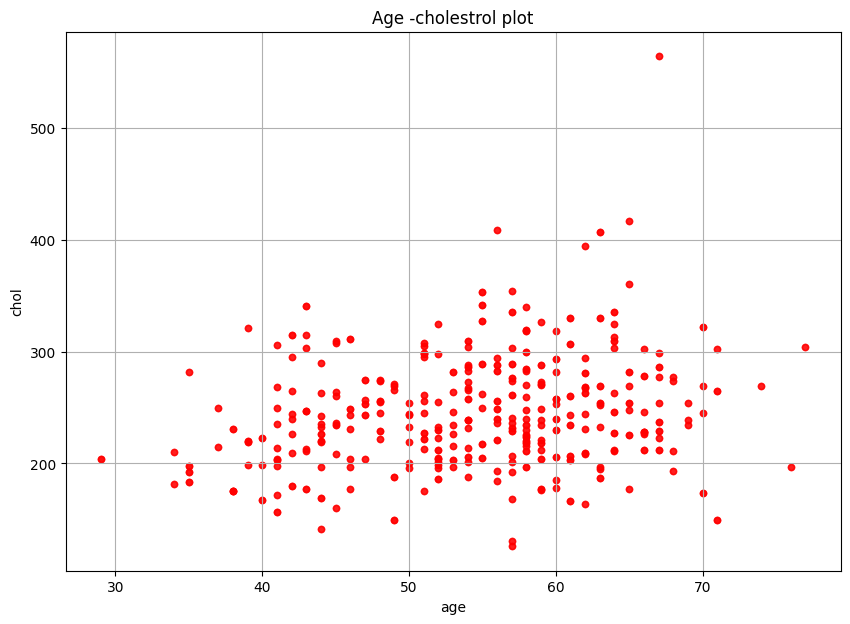

In [ ]:
import matplotlib.pyplot as plt
df.plot(kind = 'scatter', x = 'age', y = 'chol',alpha = 0.5, color = 'red', figsize = (10,7), grid = True)
plt.xlabel('age')
plt.ylabel('chol')
plt.title('Age -cholestrol plot')

In [ ]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [ ]:
#visulzation class distribution
df['target'].value_counts()
scatter = df[df['target'] == 1]
scatter= df[df['target'] == 0]


#preprossing data

In [ ]:
x = df.drop('target', axis = 1)
y = df['target']


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

GridSearchCV?

GridSearchCV tries all possible combinations of parameters and finds the best one using cross-validation.

In [ ]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV

In [ ]:
ml = svm.SVC()

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(ml, param_grid, refit=True, verbose=1,cv=15)

grid_search=grid.fit(x_train, y_train)

Fitting 15 folds for each of 18 candidates, totalling 270 fits


fetching Best Hyperparameters

In [ ]:
print(grid_search.best_params_)


{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
accuracy = grid_search.best_score_*100
print("Accuracy for our Training data with tuning is : {:.2f}%",format(accuracy))

Accuracy for our Training data with tuning is : {:.2f}% 98.16610549943884


In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=grid.predict(x_test)
test_accuracy=accuracy_score(y_test,y_pred)*100
print("Test Accuracy score ", test_accuracy)

Test Accuracy score  98.53658536585365


#Ploting A CONFUSION METRIX

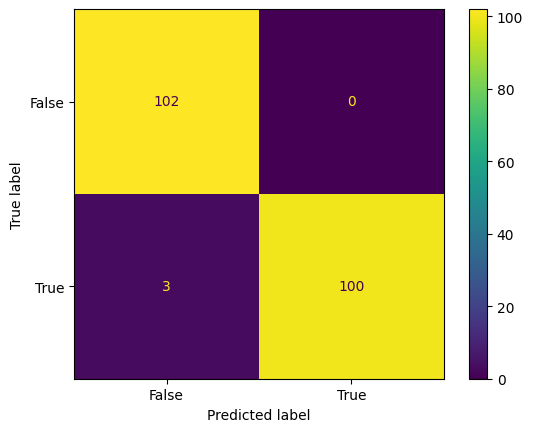

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score

confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
cm_display.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, classification_report
y_pred = grid.predict(x_test)

# Precision
precision = precision_score(y_test, y_pred, average='weighted')

# Recall
recall = recall_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)


Precision: 0.9857839721254356
Recall: 0.9853658536585366


#Roc Curve

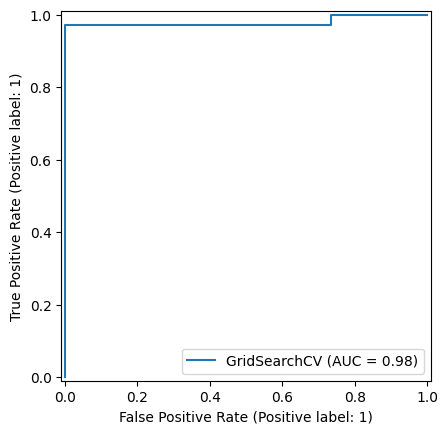

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay
RocCurveDisplay.from_estimator(grid, x_test, y_test)